In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L1_VCF     = os.path.expanduser("/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/LINE1.filtered.final.tagged.vcf.gz")
ALU_VCF    = os.path.expanduser("/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/ALU.filtered.final.tagged.vcf.gz")
OUTDIR_LEN = os.path.expanduser("/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/")
os.makedirs(OUTDIR_LEN, exist_ok=True)

In [3]:
%%bash
module load bcftools-1.21

L1_VCF=/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/LINE1.filtered.final.tagged.vcf.gz
ALU_VCF=/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/ALU.filtered.final.tagged.vcf.gz
TMPDIR_LEN=/tmp/te_lengths_$USER
mkdir -p $TMPDIR_LEN

bcftools query -f '%INFO/SVLEN\n' $L1_VCF \
  | awk '$1 != -1 {print $1}' > $TMPDIR_LEN/LINE1_lengths.txt

bcftools query -f '%INFO/SVLEN\t%INFO/ISTP\n' $L1_VCF | awk '{
  svlen=$1; istp=$2
  if (svlen==-1) { if (istp>0) print 6019-istp }
  else print svlen
}' > $TMPDIR_LEN/LINE1_lengths_istp.txt

bcftools query -f '%INFO/SVLEN\n' $ALU_VCF \
  | awk '$1 != -1 {print $1}' > $TMPDIR_LEN/ALU_lengths.txt

echo "LINE1 (SVLEN):   $(wc -l < $TMPDIR_LEN/LINE1_lengths.txt)"
echo "LINE1 (ISTP):    $(wc -l < $TMPDIR_LEN/LINE1_lengths_istp.txt)"
echo "ALU:             $(wc -l < $TMPDIR_LEN/ALU_lengths.txt)"
echo "Files written to: $TMPDIR_LEN"

[W::bcf_hdr_check_sanity] GL should be declared as Number=G
[W::bcf_hdr_check_sanity] GL should be declared as Number=G
[W::bcf_hdr_check_sanity] GL should be declared as Number=G


LINE1 (SVLEN):   5279
LINE1 (ISTP):    7075
ALU:             26977
Files written to: /tmp/te_lengths_shreyags


In [4]:
TMPDIR_LEN = f"/tmp/te_lengths_{os.environ['USER']}"  

def load_lengths(path):
    vals = pd.read_csv(path, header=None, names=["length"])["length"]
    vals = pd.to_numeric(vals, errors="coerce").abs().dropna()
    return vals[vals > 0].reset_index(drop=True)

l1_reg  = load_lengths(f"{TMPDIR_LEN}/LINE1_lengths.txt")
l1_istp = load_lengths(f"{TMPDIR_LEN}/LINE1_lengths_istp.txt")
alu     = load_lengths(f"{TMPDIR_LEN}/ALU_lengths.txt")

for label, arr in [("LINE1 (SVLEN only)", l1_reg),
                   ("LINE1 (ISTP imputed)", l1_istp),
                   ("ALU", alu)]:
    print(f"=== {label} ===")
    print(f"  N:      {len(arr)}")
    print(f"  Mean:   {arr.mean():.2f} bp")
    print(f"  Median: {arr.median():.1f} bp\n")

=== LINE1 (SVLEN only) ===
  N:      5279
  Mean:   3269.18 bp
  Median: 2845.0 bp

=== LINE1 (ISTP imputed) ===
  N:      7075
  Mean:   2751.28 bp
  Median: 1603.0 bp

=== ALU ===
  N:      26977
  Mean:   264.83 bp
  Median: 280.0 bp



  saved /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/ALU_LINE1_combined_lengths.pdf / .png


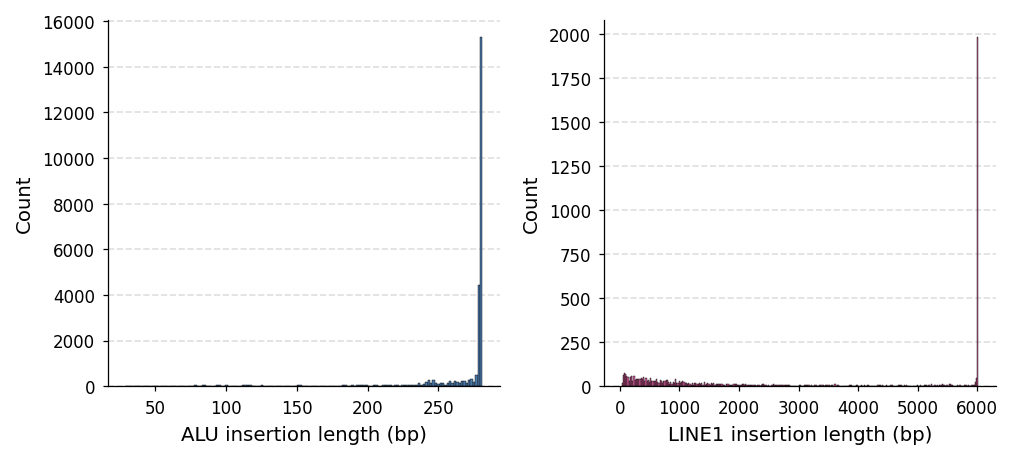

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import os
import fig_style as S

S.set_style()

OUTDIR_LEN = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures"
os.makedirs(OUTDIR_LEN, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(S.COL2, S.COL2 * 0.46), facecolor="white")

axes[0].hist(alu, bins=150, color=S.TE_PALETTE["Alu"], edgecolor="black", linewidth=0.2)
axes[0].set_xlabel("ALU insertion length (bp)")
axes[0].set_ylabel("Count")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].set_axisbelow(True)

axes[1].hist(l1_reg, bins=300, color=S.TE_PALETTE["LINE1"], edgecolor="black", linewidth=0.2)
axes[1].set_xlabel("LINE1 insertion length (bp)")
axes[1].set_ylabel("Count")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)
axes[1].set_axisbelow(True)

fig.tight_layout()
S.save(fig, os.path.join(OUTDIR_LEN, "ALU_LINE1_combined_lengths"))
plt.show()

In [16]:
import gzip
import numpy as np

def get_insertion_lengths_and_sample_bp(vcf_path):
    lengths = []
    sample_bp = None
    samples = None
    with gzip.open(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#CHROM"):
                fields = line.strip().split("\t")
                samples = fields[9:]
                sample_bp = np.zeros(len(samples), dtype=np.int64)
                continue
            if line.startswith("#"):
                continue
            fields = line.strip().split("\t")
            info = fields[7]
            svlen = None
            for entry in info.split(";"):
                if entry.startswith("SVLEN="):
                    svlen_str = entry.split("=")[1].split(",")[0]
                    try:
                        raw_svlen = int(svlen_str)
                    except ValueError:
                        raw_svlen = None
                    if raw_svlen is not None and raw_svlen > 0:
                        svlen = raw_svlen
                    break
            if svlen is None:
                continue

            lengths.append(svlen)

            genotypes = fields[9:]
            for i, gtfield in enumerate(genotypes):
                gt = gtfield.split(":")[0]
                if (
                    "1" in gt and
                    gt not in ["0/0", "0|0", "./.", ".|."]
                ):
                    sample_bp[i] += svlen

    return np.array(lengths), sample_bp, samples

alu_ins, alu_ins_sample_bp, alu_ins_samples = get_insertion_lengths_and_sample_bp(ALU_VCF)
l1_ins,  l1_ins_sample_bp,  l1_ins_samples  = get_insertion_lengths_and_sample_bp(L1_VCF)

print("ALU insertions parsed:", len(alu_ins))
print("LINE1 insertions parsed:", len(l1_ins))
print("ALU insertion mean length (bp):", np.mean(alu_ins))
print("LINE1 insertion mean length (bp):", np.mean(l1_ins))

print(
    f"On average, an individual carries ALU insertions covering "
    f"{np.mean(alu_ins_sample_bp):,.0f} bp"
)
print(
    f"On average, an individual carries LINE1 insertions covering "
    f"{np.mean(l1_ins_sample_bp):,.0f} bp"
)

ALU insertions parsed: 26977
LINE1 insertions parsed: 5279
ALU insertion mean length (bp): 264.82525855358267
LINE1 insertion mean length (bp): 3269.1782534570943
On average, an individual carries ALU insertions covering 251,660 bp
On average, an individual carries LINE1 insertions covering 241,875 bp


Parsing ALU Ins...
  n=26977  median=0.0001
Parsing LINE1 Ins...
  n=7075  median=0.0001
  saved /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/ALU_LINE1_ins_AF_distribution.pdf / .png


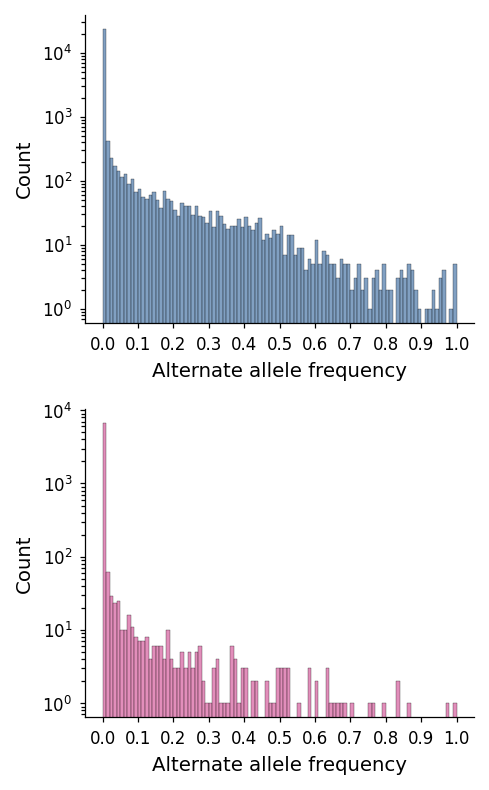

In [13]:
import os
import gzip
import numpy as np
import matplotlib.pyplot as plt
import fig_style as S

S.set_style()

ALU_INS_VCF = "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/ALU.filtered.final.tagged.vcf.gz"
L1_INS_VCF  = "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/LINE1.filtered.final.tagged.vcf.gz"

OUTDIR = os.path.expanduser(
    "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/"
)
os.makedirs(OUTDIR, exist_ok=True)

GROUPS = [
    ("ALU Ins",   S.TE_PALETTE["Alu"],   ALU_INS_VCF),
    ("LINE1 Ins", S.TE_PALETTE["LINE1"], L1_INS_VCF),
]

def get_af(vcf_path):
    afs = []
    with gzip.open(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue
            for entry in line.strip().split("\t")[7].split(";"):
                if entry.startswith("AF="):
                    try:
                        afs.append(float(entry.split("=")[1].split(",")[0]))
                    except ValueError:
                        pass
                    break
    return np.array(afs)

fig, axes = plt.subplots(2, 1, figsize=(S.COL1, S.COL1 * 1.6), facecolor="white")

for ax, (label, color, vcf) in zip(axes, GROUPS):
    print(f"Parsing {label}...")
    af = get_af(vcf)
    print(f"  n={len(af)}  median={np.median(af):.4f}")

    ax.hist(af, bins=np.arange(0, 1.01, 0.01),
            color=color, ec="black", linewidth=0.2, alpha=0.7)
    ax.set_yscale("log")
    ax.set_xticks(np.arange(0, 1.05, 0.1))
    ax.set_ylabel("Count")
    ax.set_xlabel("Alternate allele frequency")
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
S.save(fig, os.path.join(OUTDIR, "ALU_LINE1_ins_AF_distribution"))
plt.show()

In [20]:
%%bash
module load bcftools-1.21

L1_VCF=/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/LINE1.filtered.final.tagged.vcf.gz
ALU_VCF=/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/ALU.filtered.final.tagged.vcf.gz
TMPDIR_LEN=/tmp/te_lengths_$USER
mkdir -p $TMPDIR_LEN

bcftools query -f '%CHROM\n' $ALU_VCF > $TMPDIR_LEN/ALU_chroms.txt
bcftools query -f '%CHROM\n' $L1_VCF  > $TMPDIR_LEN/LINE1_chroms.txt

echo "ALU records:   $(wc -l < $TMPDIR_LEN/ALU_chroms.txt)"
echo "LINE1 records: $(wc -l < $TMPDIR_LEN/LINE1_chroms.txt)"

[W::bcf_hdr_check_sanity] GL should be declared as Number=G
[W::bcf_hdr_check_sanity] GL should be declared as Number=G


ALU records:   26977
LINE1 records: 7075


ALU / All: n=26977
ALU / Non-singletons: n=14607
ALU / Common: n=3029
LINE1 / All: n=5279
LINE1 / Non-singletons: n=2596
LINE1 / Common: n=284
  saved /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/ALU_LINE1_length_vs_AF_by_category.pdf / .png


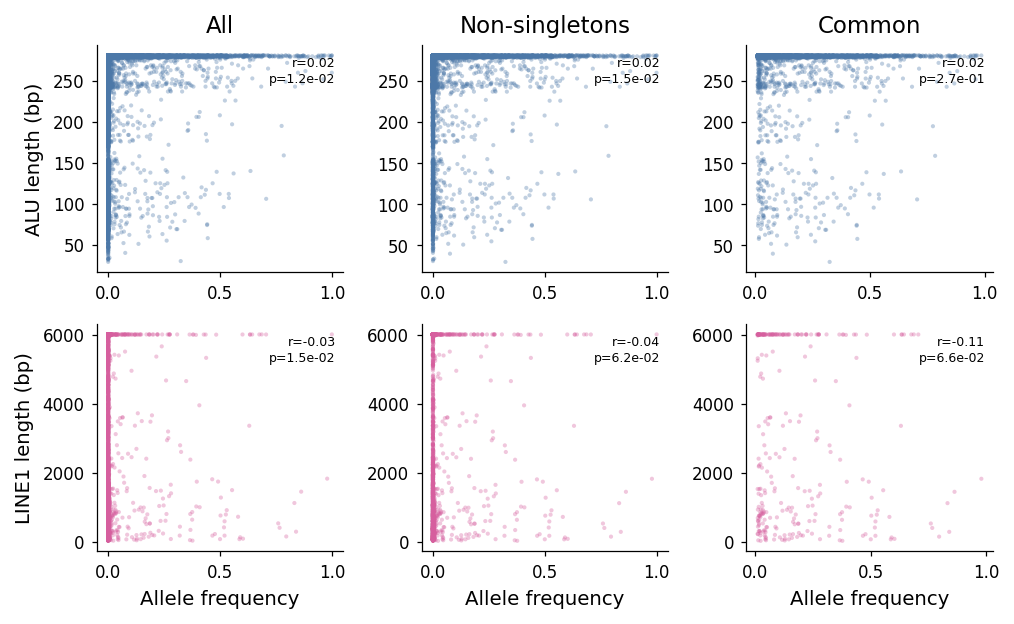

In [20]:
import os
import gzip
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import fig_style as S

S.set_style()

CATEGORIES = [
    ("All",  "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/ALU.filtered.final.tagged.vcf.gz",  "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/with_af_new_final/LINE1.filtered.final.tagged.vcf.gz"),
    ("Non-singletons",    "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/common_nosingletons_new_final/ALU.filtered.final.no_singletons.vcf.gz",    "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/common_nosingletons_new_final/LINE1.filtered.final.no_singletons.vcf.gz"),
    ("Common",   "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/common_nosingletons_new_final/ALU.filtered.final.common_maf0.01.vcf.gz",   "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/common_nosingletons_new_final/LINE1.filtered.final.common_maf0.01.vcf.gz"),
]

OUTDIR = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures"
os.makedirs(OUTDIR, exist_ok=True)

#pull AF and SVLEN from VCF INFO field

def get_af_length(vcf_path):
    afs, lengths = [], []
    opener = gzip.open if vcf_path.endswith(".gz") else open
    with opener(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue
            info = line.rstrip("\n").split("\t")[7]
            af = None
            svlen_raw = None
            for entry in info.split(";"):
                if entry.startswith("AF="):
                    try:
                        af = float(entry.split("=", 1)[1].split(",")[0])
                    except ValueError:
                        pass
                elif entry.startswith("SVLEN="):
                    try:
                        svlen_raw = float(entry.split("=", 1)[1].split(",")[0])
                    except ValueError:
                        pass
            # explicitly exclude the SVLEN=-1
            if svlen_raw is not None and svlen_raw == -1:
                continue

            if af is not None and svlen_raw is not None:
                afs.append(af)
                lengths.append(abs(svlen_raw))
    return np.array(afs), np.array(lengths)

#PLOT 
TE_ROWS = [("ALU", S.TE_PALETTE["Alu"], 1), ("LINE1", S.TE_PALETTE["LINE1"], 2)]

fig, axes = plt.subplots(2, 3, figsize=(S.COL2, S.COL2 * 0.62), facecolor="white")

for row_i, (te_label, color, vcf_idx) in enumerate(TE_ROWS):
    for col_i, cat_entry in enumerate(CATEGORIES):
        cat_label = cat_entry[0]
        vcf_path = cat_entry[vcf_idx]
        ax = axes[row_i, col_i]
        ax.set_facecolor("white")

        af, length = get_af_length(vcf_path)
        print(f"{te_label} / {cat_label}: n={len(af)}")

        ax.scatter(af, length, s=4, alpha=0.35, color=color, edgecolor="none")

        if len(af) > 2:
            r, p = pearsonr(af, length)
            ax.text(
                0.97, 0.95,
                f"r={r:.2f}\np={p:.1e}",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=6, color="black",
                linespacing=1.3,
            )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if row_i == 0:
            ax.set_title(cat_label)
        if row_i == 1:
            ax.set_xlabel("Allele frequency")
        if col_i == 0:
            ax.set_ylabel(f"{te_label} length (bp)")

fig.tight_layout()
S.save(fig, os.path.join(OUTDIR, "ALU_LINE1_length_vs_AF_by_category"))
plt.show()

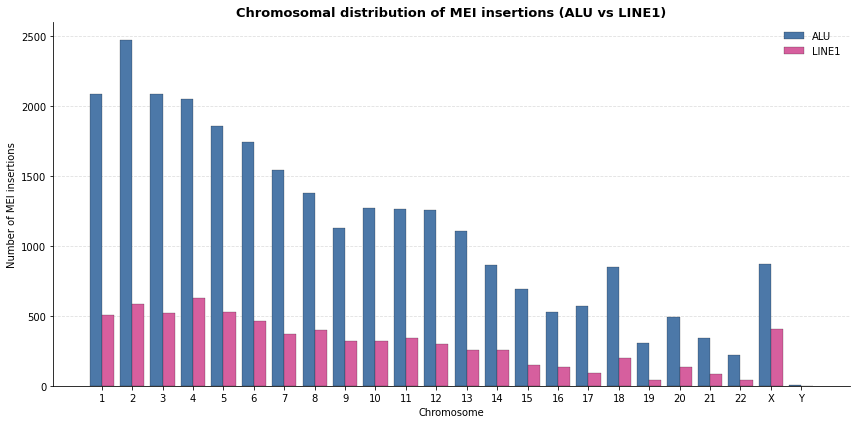

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

TMPDIR_LEN = f"/tmp/te_lengths_{os.environ['USER']}"

chrom_order = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"] # adjust prefix if your VCF uses "1" not "chr1"

def load_chrom_counts(path):
    chroms = pd.read_csv(path, header=None, names=["chrom"])["chrom"]
    counts = chroms.value_counts()
    return counts.reindex(chrom_order, fill_value=0)

alu_counts = load_chrom_counts(f"{TMPDIR_LEN}/ALU_chroms.txt")
l1_counts  = load_chrom_counts(f"{TMPDIR_LEN}/LINE1_chroms.txt")

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")

x = np.arange(len(chrom_order))
width = 0.4

ax.bar(
    x - width/2,
    alu_counts.values,
    width=width,
    label="ALU",
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.2
)
ax.bar(
    x + width/2,
    l1_counts.values,
    width=width,
    label="LINE1",
    color="#D65F9E",
    edgecolor="black",
    linewidth=0.2
)

ax.set_xlabel("Chromosome")
ax.set_ylabel("Number of MEI insertions")
ax.set_title(
    "Chromosomal distribution of MEI insertions (ALU vs LINE1)",
    fontsize=13,
    fontweight="bold"
)
ax.set_xticks(x)
ax.set_xticklabels([c.replace("chr", "") for c in chrom_order])
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    f"{OUTDIR_LEN}/ALU_LINE1_chromosome_distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

Loading All variants...
  All 7478 samples matched to a group.
Loading Non-singletons...
  All 7478 samples matched to a group.
  saved /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures/pca_all_vs_nosing.pdf / .png


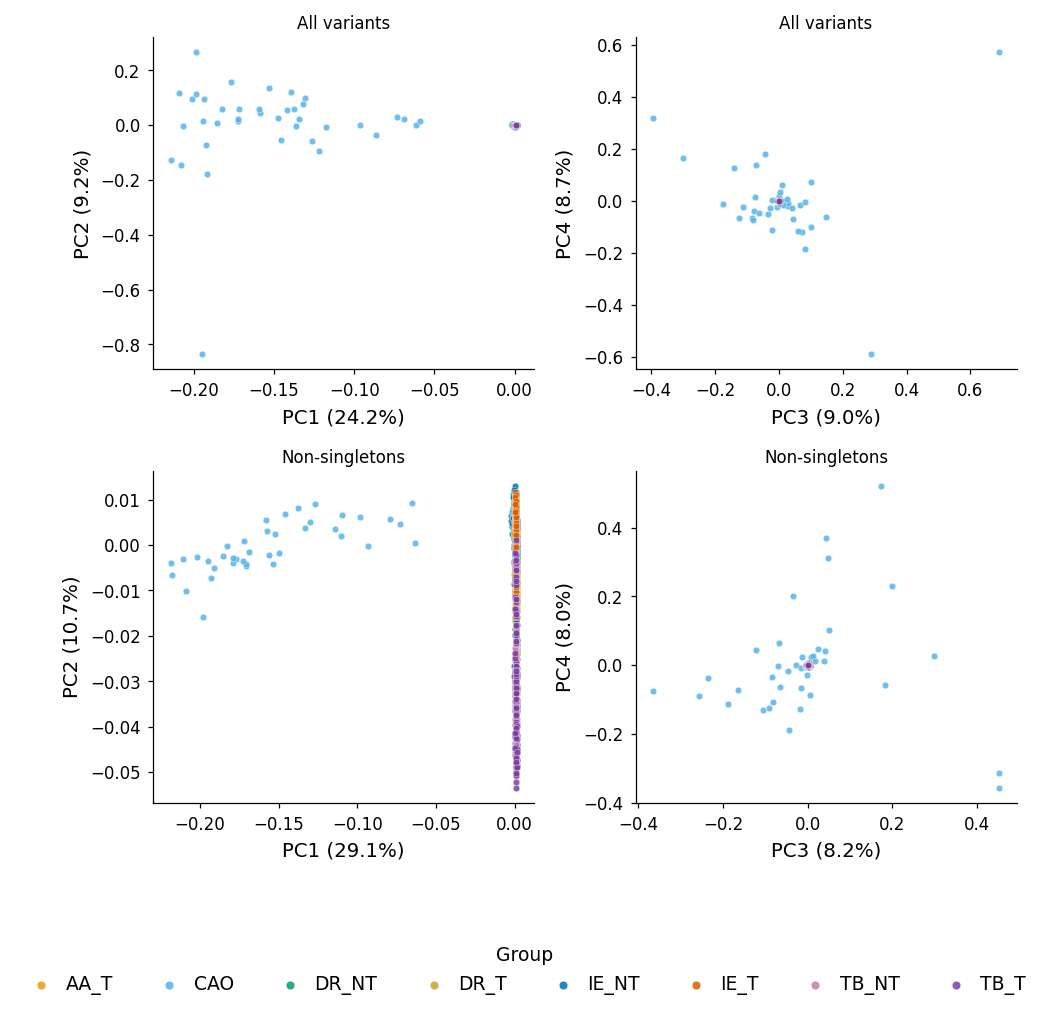

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import fig_style as S

S.set_style()

DATASETS = [
    ("All variants",   "/gpfs/data/user/shreyags/TE_work/analysis/INS_PCA_all/ALU_LINE1.merged.pca.eigenvec",        "/gpfs/data/user/shreyags/TE_work/analysis/INS_PCA_all/ALU_LINE1.merged.pca.eigenval"),
    ("Non-singletons", "/gpfs/data/user/shreyags/TE_work/analysis/INS_PCA_nosing_only/ALU_LINE1.merged.pca.eigenvec", "/gpfs/data/user/shreyags/TE_work/analysis/INS_PCA_nosing_only/ALU_LINE1.merged.pca.eigenval"),
]

METADATA_PATH = "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/sample_population_map.csv"
SAMPLE_ID_COL = 0
LING_COL      = 2
TRIBE_COL     = 3

PALETTE       = S.GROUP_PALETTE
PALETTE_ORDER = S.GROUP_ORDER

OUTDIR  = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_figures"
OUTPATH = os.path.join(OUTDIR, "pca_all_vs_nosing")
os.makedirs(OUTDIR, exist_ok=True)

PC_PAIRS = [("PC1", "PC2"), ("PC3", "PC4")]

meta = pd.read_csv(METADATA_PATH)
sample_col, ling_col, tribe_col = meta.columns[[SAMPLE_ID_COL, LING_COL, TRIBE_COL]]
meta["group"] = meta.apply(lambda r: S.group_label(r[ling_col], r[tribe_col]), axis=1)


def load_pca(eigenvec_path, eigenval_path):
    eigenvec = pd.read_csv(eigenvec_path, sep="\t")
    eigenvec = eigenvec.rename(columns={"#IID": "IID"})
    eigenvec["IID_stripped"] = eigenvec["IID"].str.split("_", n=1).str[0]

    eigenval = pd.read_csv(eigenval_path, header=None, names=["eigenval"])["eigenval"]
    pct_var = 100 * eigenval / eigenval.sum()

    eigenvec = eigenvec.merge(
        meta[[sample_col, "group"]], left_on="IID_stripped", right_on=sample_col, how="left"
    )

    n_unmatched = eigenvec["group"].isna().sum()
    if n_unmatched:
        print(f"  [warn] {n_unmatched}/{len(eigenvec)} samples had no metadata match")
    else:
        print(f"  All {len(eigenvec)} samples matched to a group.")

    return eigenvec, pct_var

fig, axes = plt.subplots(2, 2, figsize=(S.COL2, S.COL2 * 0.92), facecolor="white")

for row_i, (ds_label, evec_path, eval_path) in enumerate(DATASETS):
    print(f"Loading {ds_label}...")
    eigenvec, pct_var = load_pca(evec_path, eval_path)

    for col_i, (px, py) in enumerate(PC_PAIRS):
        ax = axes[row_i, col_i]
        ax.set_facecolor("white")

        for grp in PALETTE_ORDER:
            sub = eigenvec[eigenvec["group"] == grp]
            if sub.empty:
                continue
            ax.scatter(
                sub[px], sub[py],
                s=10, alpha=0.85,
                color=PALETTE[grp],
                edgecolor="white", linewidth=0.2,
                label=grp,
            )

        px_n, py_n = int(px[2:]), int(py[2:])
        ax.set_xlabel(f"{px} ({pct_var.iloc[px_n - 1]:.1f}%)")
        ax.set_ylabel(f"{py} ({pct_var.iloc[py_n - 1]:.1f}%)")
        ax.set_title(ds_label, fontsize=S.FS_TICK, pad=4)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, title="Group", frameon=False,
    loc="upper center", bbox_to_anchor=(0.5, 0.01),
    ncol=len(PALETTE_ORDER),
    markerscale=1.3, handletextpad=0.3,
)

fig.tight_layout(rect=[0.03, 0.06, 1, 1])
S.save(fig, OUTPATH)
plt.show()